# Contour overplots: L1 tomo vs bin3, and L1 tomo vs CNN tomo

This notebook produces two comparison plots from saved posterior samples:

1. **L1 + jaxili (no PCA):** tomographic `(1,2,3,4)` vs single-bin `(3)`.
2. **Tomographic comparison:** L1 + jaxili (no PCA) vs CNN-based tomo posterior.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from getdist import MCSamples, plots as gplots

plt.rcParams['figure.dpi'] = 120
from IPython.display import Image, display


In [9]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'scripts' / 'sbi').exists():
            return p
    raise FileNotFoundError('Could not locate repo root containing scripts/sbi')

ROOT = find_repo_root(Path.cwd())
ROOT


PosixPath('/mnt/home/tersenov/software/cnn_sbi')

In [10]:
posterior_paths = {
    'l1_tomo_nopca': ROOT / 'scripts/sbi/l1_pca_sweep/posteriors/nopca_tomo4_seed42.npy',
    'l1_bin3_nopca': ROOT / 'scripts/sbi/l1_pca_sweep/posteriors/nopca_bin3_seed42.npy',
    'cnn_tomo': ROOT / 'scripts/sbi/systematic_runs_cnn_retrain_proper/posteriors/cnn_tomo4_20deg160_s42.npy',
}

for name, path in posterior_paths.items():
    print(f'{name}: {path}')
    if not path.exists():
        raise FileNotFoundError(f'Missing posterior file: {path}')

samples = {name: np.load(path) for name, path in posterior_paths.items()}

for name, arr in samples.items():
    print(f'{name}: shape={arr.shape}, finite={np.isfinite(arr).all()}')
    if arr.ndim != 2 or arr.shape[1] != 6:
        raise ValueError(f'Unexpected shape for {name}: {arr.shape}')
    if not np.isfinite(arr).all():
        raise ValueError(f'Non-finite values found in {name}')


l1_tomo_nopca: /mnt/home/tersenov/software/cnn_sbi/scripts/sbi/l1_pca_sweep/posteriors/nopca_tomo4_seed42.npy
l1_bin3_nopca: /mnt/home/tersenov/software/cnn_sbi/scripts/sbi/l1_pca_sweep/posteriors/nopca_bin3_seed42.npy
cnn_tomo: /mnt/home/tersenov/software/cnn_sbi/scripts/sbi/systematic_runs_cnn_retrain_proper/posteriors/cnn_tomo4_20deg160_s42.npy
l1_tomo_nopca: shape=(100000, 6), finite=True
l1_bin3_nopca: shape=(100000, 6), finite=True
cnn_tomo: shape=(10000, 6), finite=True


In [11]:
param_names = ['Omega_m', 'S8', 'w0', 'h0', 'ns', 'Omega_b']
param_labels = ['Omega_m', 'S8', 'w0', 'h0', 'ns', 'Omega_b']
truth = np.array([0.26, 0.84, -1.0, 0.6736, 0.9649, 0.0493], dtype=np.float32)


def to_mcs(arr: np.ndarray, label: str) -> MCSamples:
    return MCSamples(samples=arr, names=param_names, labels=param_labels, label=label)


def make_triangle(sample_list, legend_labels, title, colors):
    g = gplots.get_subplot_plotter(subplot_size=1.8)
    g.settings.alpha_filled_add = 0.5
    g.settings.legend_fontsize = 12
    g.settings.axes_fontsize = 11
    g.triangle_plot(
        sample_list,
        filled=True,
        contour_colors=colors,
        legend_labels=legend_labels,
        markers=truth,
    )
    g.fig.suptitle(title, y=1.02)
    return g


l1_tomo_mcs = to_mcs(samples['l1_tomo_nopca'], 'L1 tomo (1,2,3,4), no PCA')
l1_bin3_mcs = to_mcs(samples['l1_bin3_nopca'], 'L1 bin3, no PCA')
cnn_tomo_mcs = to_mcs(samples['cnn_tomo'], 'CNN tomo (20deg160, s42)')


Removed no burn in
Removed no burn in
Removed no burn in


In [12]:
g1 = make_triangle(
    [l1_tomo_mcs, l1_bin3_mcs],
    ['L1 tomo (1,2,3,4), no PCA', 'L1 bin3, no PCA'],
    'L1 + jaxili (no PCA): tomographic vs bin 3',
    ['#1f77b4', '#ff7f0e'],
)
display(g1.fig)


<Figure size 1296x1296 with 21 Axes>

In [13]:
g2 = make_triangle(
    [l1_tomo_mcs, cnn_tomo_mcs],
    ['L1 tomo (1,2,3,4), no PCA', 'CNN tomo'],
    'Tomographic comparison: L1 + jaxili (no PCA) vs CNN',
    ['#1f77b4', '#2ca02c'],
)
display(g2.fig)


<Figure size 1296x1296 with 21 Axes>

Saved: /mnt/home/tersenov/software/cnn_sbi/scripts/sbi/l1_pca_sweep/figures/overplot_l1_tomo_vs_bin3_nopca.png
Saved: /mnt/home/tersenov/software/cnn_sbi/scripts/sbi/l1_pca_sweep/figures/overplot_l1_tomo_vs_cnn_tomo.png


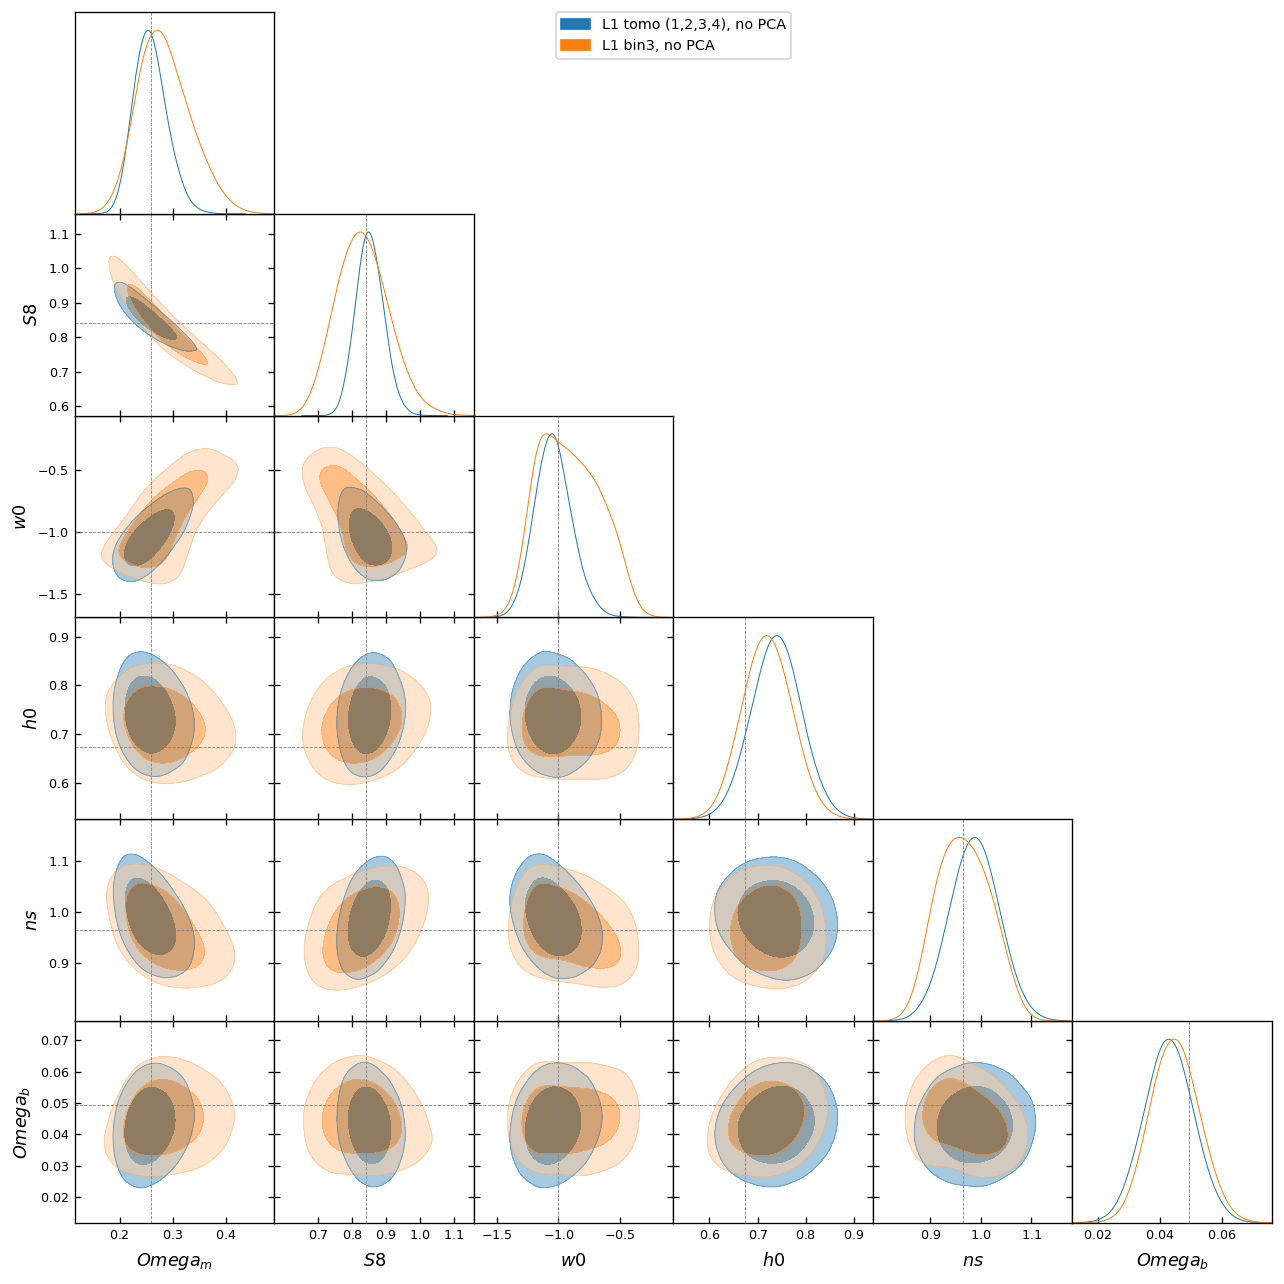

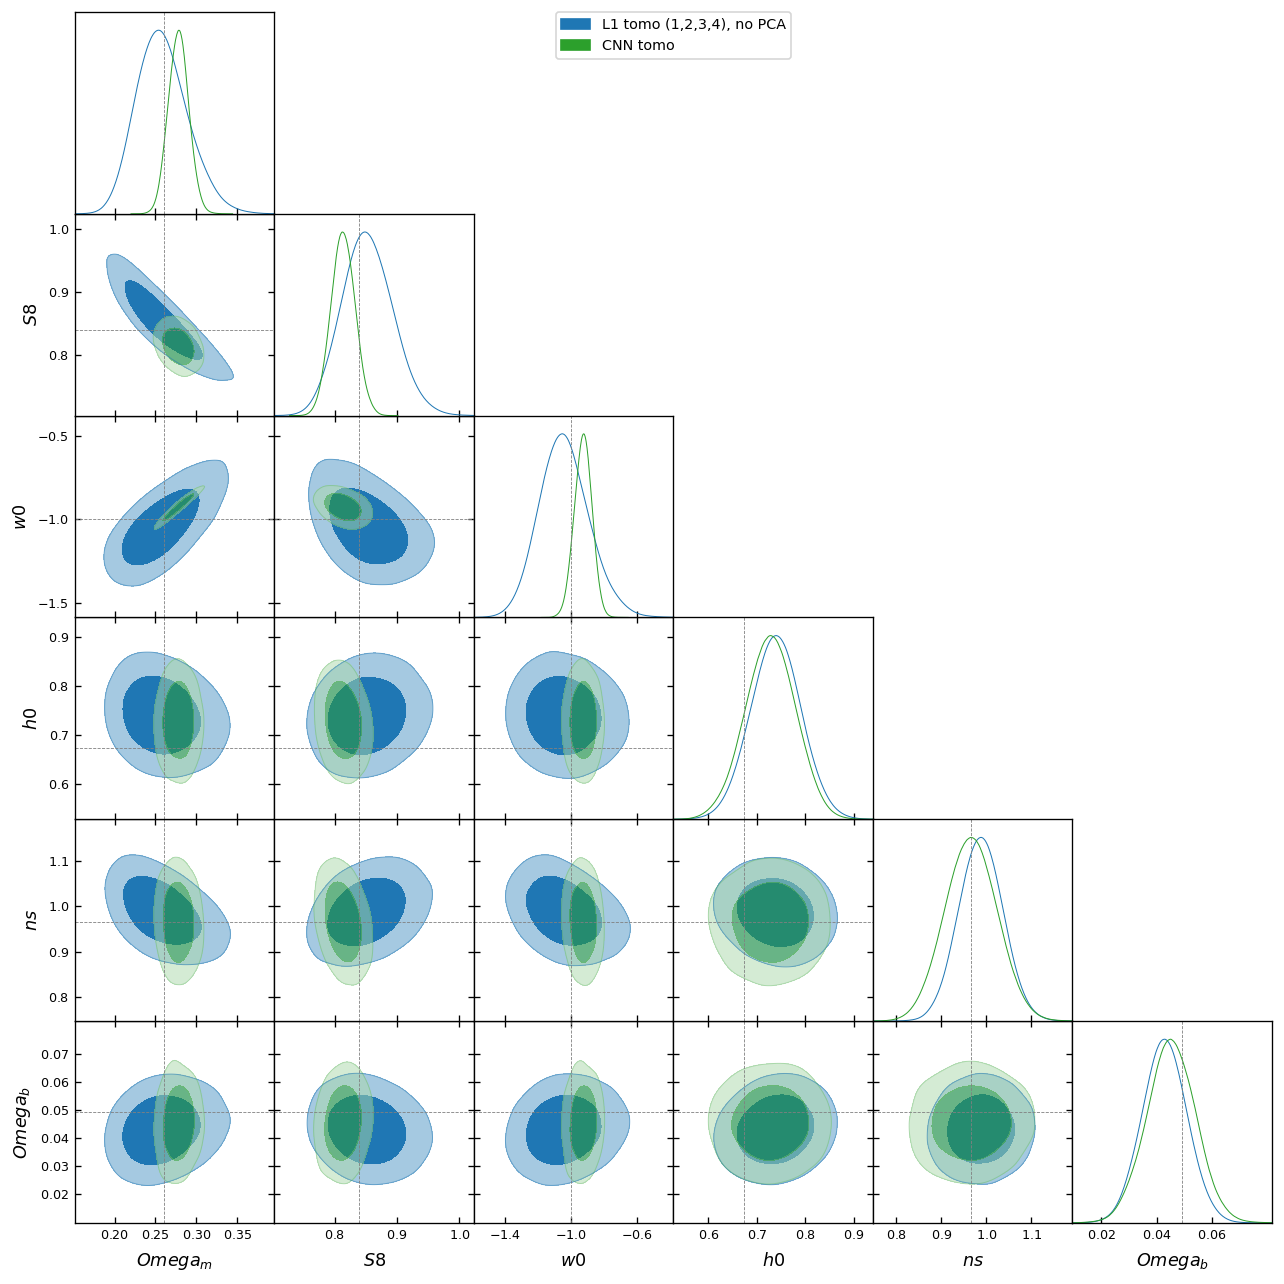

In [14]:
out_dir = ROOT / 'scripts/sbi/l1_pca_sweep/figures'
out_dir.mkdir(parents=True, exist_ok=True)

save1 = out_dir / 'overplot_l1_tomo_vs_bin3_nopca.png'
save2 = out_dir / 'overplot_l1_tomo_vs_cnn_tomo.png'

g1.export(str(save1))
g2.export(str(save2))

print('Saved:', save1)
print('Saved:', save2)

display(Image(filename=str(save1)))
display(Image(filename=str(save2)))
